**IMPORT LIBRARY**



In [ ]:
# **Steps**
# 1-> Preprocess + EDA + Feature Selection
# 2-> Extract input and output
# 3-> Scale the values
# 4-> Train test split
# 5-> Train the model
# 6-> Evaluate the model/model selection
# 7-> Deploy the model

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df=pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape


(100, 4)

In [ ]:
df = df.iloc[:,1:]

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [ ]:
df.isnull().sum()

,0
cgpa,0
iq,0
placement,0


In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
import matplotlib.pyplot as plt


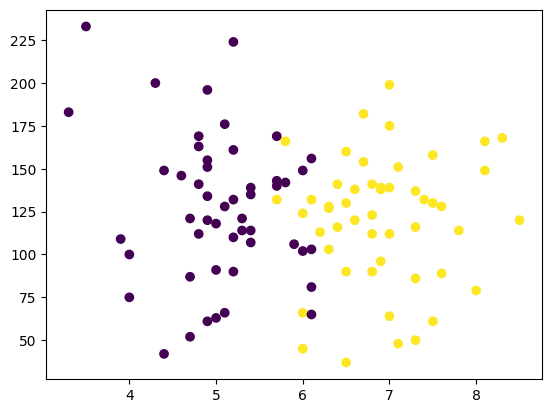

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])


In [ ]:
# After Seeing the graph(EDA), we say that logistic regression
# (divide the graph into 2 parts using a single line)
# will be good model

#**Extract input and output**

In [ ]:
X=df.iloc[:,:2]
y=df.iloc[:,-1]


In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
y.shape


(100,)

#**Train test split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=2)


In [ ]:
X_train

,cgpa,iq
99,6.2,113.0
92,5.2,110.0
76,4.9,155.0
14,6.1,103.0
0,6.8,123.0
...,...,...
43,6.8,141.0
22,4.9,120.0
72,7.3,116.0
15,5.1,176.0


In [ ]:
y_train

,placement
99,1
92,0
76,0
14,0
0,1
...,...
43,1
22,0
72,1
15,0


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [ ]:
X_train

array([[ 0.16981077, -0.27485148],
       [-0.69853978, -0.35042165],
       [-0.95904494,  0.7831308 ],
       [ 0.08297572, -0.52675203],
       [ 0.6908211 , -0.02295094],
       [ 0.95132627,  0.68237059],
       [ 1.21183143,  0.20375955],
       [ 0.86449121, -0.30004154],
       [ 1.12499638,  0.32970982],
       [ 0.43031594, -0.85422273],
       [ 0.6908211 , -0.85422273],
       [ 0.77765616,  0.35489988],
       [-0.2643645 ,  1.13579157],
       [ 1.29866649, -1.58473431],
       [-0.95904494, -1.58473431],
       [ 0.95132627, -1.91220502],
       [-0.87220989, -0.82903268],
       [ 1.12499638, -1.86182491],
       [ 0.60398605,  0.75794075],
       [-0.00385934, -0.55194208],
       [ 1.81967682,  1.0602214 ],
       [-0.09069439, -0.45118186],
       [-1.74056044, -0.60232219],
       [ 0.51715099,  0.35489988],
       [-0.2643645 ,  0.40527999],
       [ 0.08297572, -1.08093322],
       [-0.2643645 ,  0.48085015],
       [-0.95904494,  0.68237059],
       [ 1.29866649,

In [ ]:
X_test=scaler.transform(X_test)

In [ ]:
X_test

array([[ 1.29866649e+00,  1.53379443e-01],
       [ 1.38550154e+00,  1.02999334e-01],
       [ 8.29757193e-02, -1.48397410e+00],
       [-1.13271505e+00, -7.33310473e-02],
       [-6.98539776e-01,  2.52124456e+00],
       [-1.13271505e+00, -9.29792898e-01],
       [-6.11704721e-01, -7.33310473e-02],
       [-3.85933578e-03,  2.23911595e-03],
       [-6.98539776e-01, -8.54222735e-01],
       [ 3.43480884e-01, -1.99281319e-01]])

#**Model Training**

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_predict=model.predict(X_test)

In [ ]:
y_predict

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 1])

In [ ]:
y_test

,placement
83,1
30,1
56,0
24,0
16,0
23,0
2,0
27,1
28,0
13,1


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predict)

0.9

<Axes: >

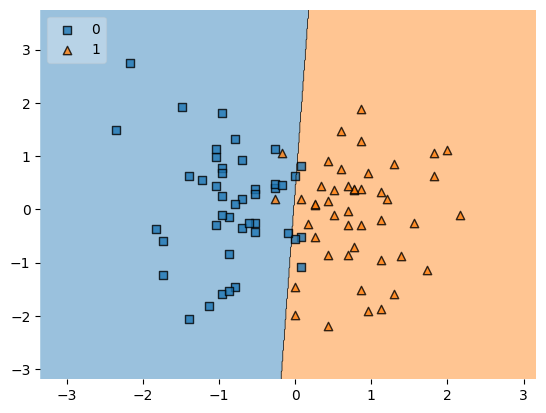

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,y_train.values,clf=model,legend=2)

In [ ]:
import pickle

In [ ]:
pickle.dump(model,open('model.pkl','wb'))